<a href="https://www.kaggle.com/code/skailshvenkat/fem-fdm?scriptVersionId=228635771" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image  

dataset_path = '/kaggle/input/normal/NORMAL' 
image_size = (128, 128)  # Target image size

def load_images(dataset_path, image_size=(128, 128)):
    images = []
    for img_name in os.listdir(dataset_path):
        img_path = os.path.join(dataset_path, img_name)
        img = image.load_img(img_path, target_size=image_size)  
        img = image.img_to_array(img)  
        img = img / 255.0 
        images.append(img)
    return np.array(images)

images = load_images(dataset_path)


In [ ]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_complex_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Flatten()(x)
    latent = layers.Dense(256, activation="relu")(x)

    return models.Model(inputs, latent, name="Complex_Encoder")



In [ ]:
def build_complex_decoder(latent_dim=256, target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16 * 16 * 128, activation="relu")(inputs)
    x = layers.Reshape((16, 16, 128))(x)

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x
                                   )
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Complex_Decoder")



In [ ]:
import tensorflow.keras.backend as K

In [ ]:
from skimage.metrics import structural_similarity as ssim

In [ ]:
def combined_loss(y_true, y_pred):
    mse_loss = K.mean(K.square(y_true - y_pred))
    ssim_loss = K.mean(1 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.99 * mse_loss + 0.01 * ssim_loss

def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_complex_encoder(input_shape)
    decoder = build_complex_decoder(latent_dim=256, target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    latent = encoder(inputs)
    reconstructed = decoder(latent)

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss=combined_loss)
    return autoencoder

In [ ]:
X_train1, X_val = train_test_split(X_train, test_size=0.2, random_state=42)

In [ ]:
X_train=X_train1

In [ ]:
import tensorflow as tf

In [2]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import History

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

start_time = time.time()

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=67,
    batch_size=16,
    callbacks=[History()]  
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

fig, ax1 = plt.subplots()

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history.epoch, history.history['loss'], 'r-', label='Training Loss')
ax1.plot(history.epoch, history.history['val_loss'], 'r--', label='Validation Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

plt.title("Training and Validation Metrics")
plt.show()

NameError: name 'build_autoencoder' is not defined

In [ ]:
from skimage.metrics import structural_similarity as ssim

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Function to compute MSE
def calculate_mse(image1, image2):
    return np.mean((image1 - image2) ** 2)

# Measure testing time for each input separately
testing_times = []
decoded_imgs = []
ssim_values = []

for i in range(len(X_test)):
    test_start_time = time.time()
    decoded_img = autoencoder.predict(X_test[i:i+1])  # Predict one image at a time
    test_end_time = time.time()
    
    testing_time = test_end_time - test_start_time
    testing_times.append(testing_time)
    decoded_imgs.append(decoded_img[0])
    x = calculate_mse(X_test[i], decoded_img[0])
    

    ssim_value = 1 - x
    ssim_values.append(ssim_value)
    
    print(f"Testing time for image {i+1}: {testing_time:.5f} sec, MSE: {mse_value:.5f}, SSIM: {ssim_value:.5f}")

# Compute total and average testing time
total_testing_time = sum(testing_times)
average_testing_time = total_testing_time / len(X_test)

print(f"Total testing time: {total_testing_time:.2f} seconds")
print(f"Average testing time per image: {average_testing_time:.5f} seconds")

print(f"Total testing time: {total_testing_time:.2f} seconds")
print(f"Average testing time per image: {average_testing_time:.5f} seconds")

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
decoded_imgs = autoencoder.predict(X_train)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
encoder = autoencoder.get_layer("Complex_Encoder")
encoder.summary() 

In [ ]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Model


layer_name = "batch_normalization"  
# Create a model that outputs the activations of the batch norm layer
intermediate_model = Model(inputs=encoder.input, outputs=encoder.get_layer(layer_name).output)

# Extract gamma and beta values
bn_layer = encoder.get_layer(layer_name)
gamma, beta = bn_layer.get_weights()[0], bn_layer.get_weights()[1]

# Define the number of batches to process
num_batches = 10
batch_size = 16

mean_list = []
var_list = []

for i in range(num_batches):
    sample_batch = X_train[i * batch_size : (i + 1) * batch_size]  # Extract batch
    activations = intermediate_model.predict(sample_batch)

    # Compute mean and variance
    mean_values = np.mean(activations, axis=(0, 1, 2))
    var_values = np.var(activations, axis=(0, 1, 2))

    mean_list.extend(mean_values)
    var_list.extend(var_values)

# Convert lists to numpy arrays
mean_list = np.array(mean_list)
var_list = np.array(var_list)

# Plot mean distribution
plt.figure(figsize=(8, 5))
plt.hist(mean_list, bins=50, color='b', alpha=0.7)
plt.axvline(0, color='r', linestyle="--", label="Expected Mean (0)")
plt.title("Mean of Batch Normalization Output Across Batches")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.xlim(-0.1,0.2)
plt.legend()
plt.show()

# Plot variance distribution
plt.figure(figsize=(8, 5))
plt.hist(var_list, bins=50, color='g', alpha=0.7)
plt.axvline(1, color='r', linestyle="--", label="Expected Variance (1)")
plt.title("Variance of Batch Normalization Output Across Batches")
plt.xlabel("Variance Value")
plt.ylabel("Frequency")
plt.xlim(0.2,1.2)
plt.legend()
plt.show()

# Print mean and variance ranges
print(f"Mean range: {mean_list.min()} to {mean_list.max()}")
print(f"Variance range: {var_list.min()} to {var_list.max()}")

# Print gamma and beta values
print("\nGamma (Scale) values:")
print(gamma)

print("\nBeta (Shift) values:")
print(beta)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
Feature Maps Shape: (1, 32, 32, 64)


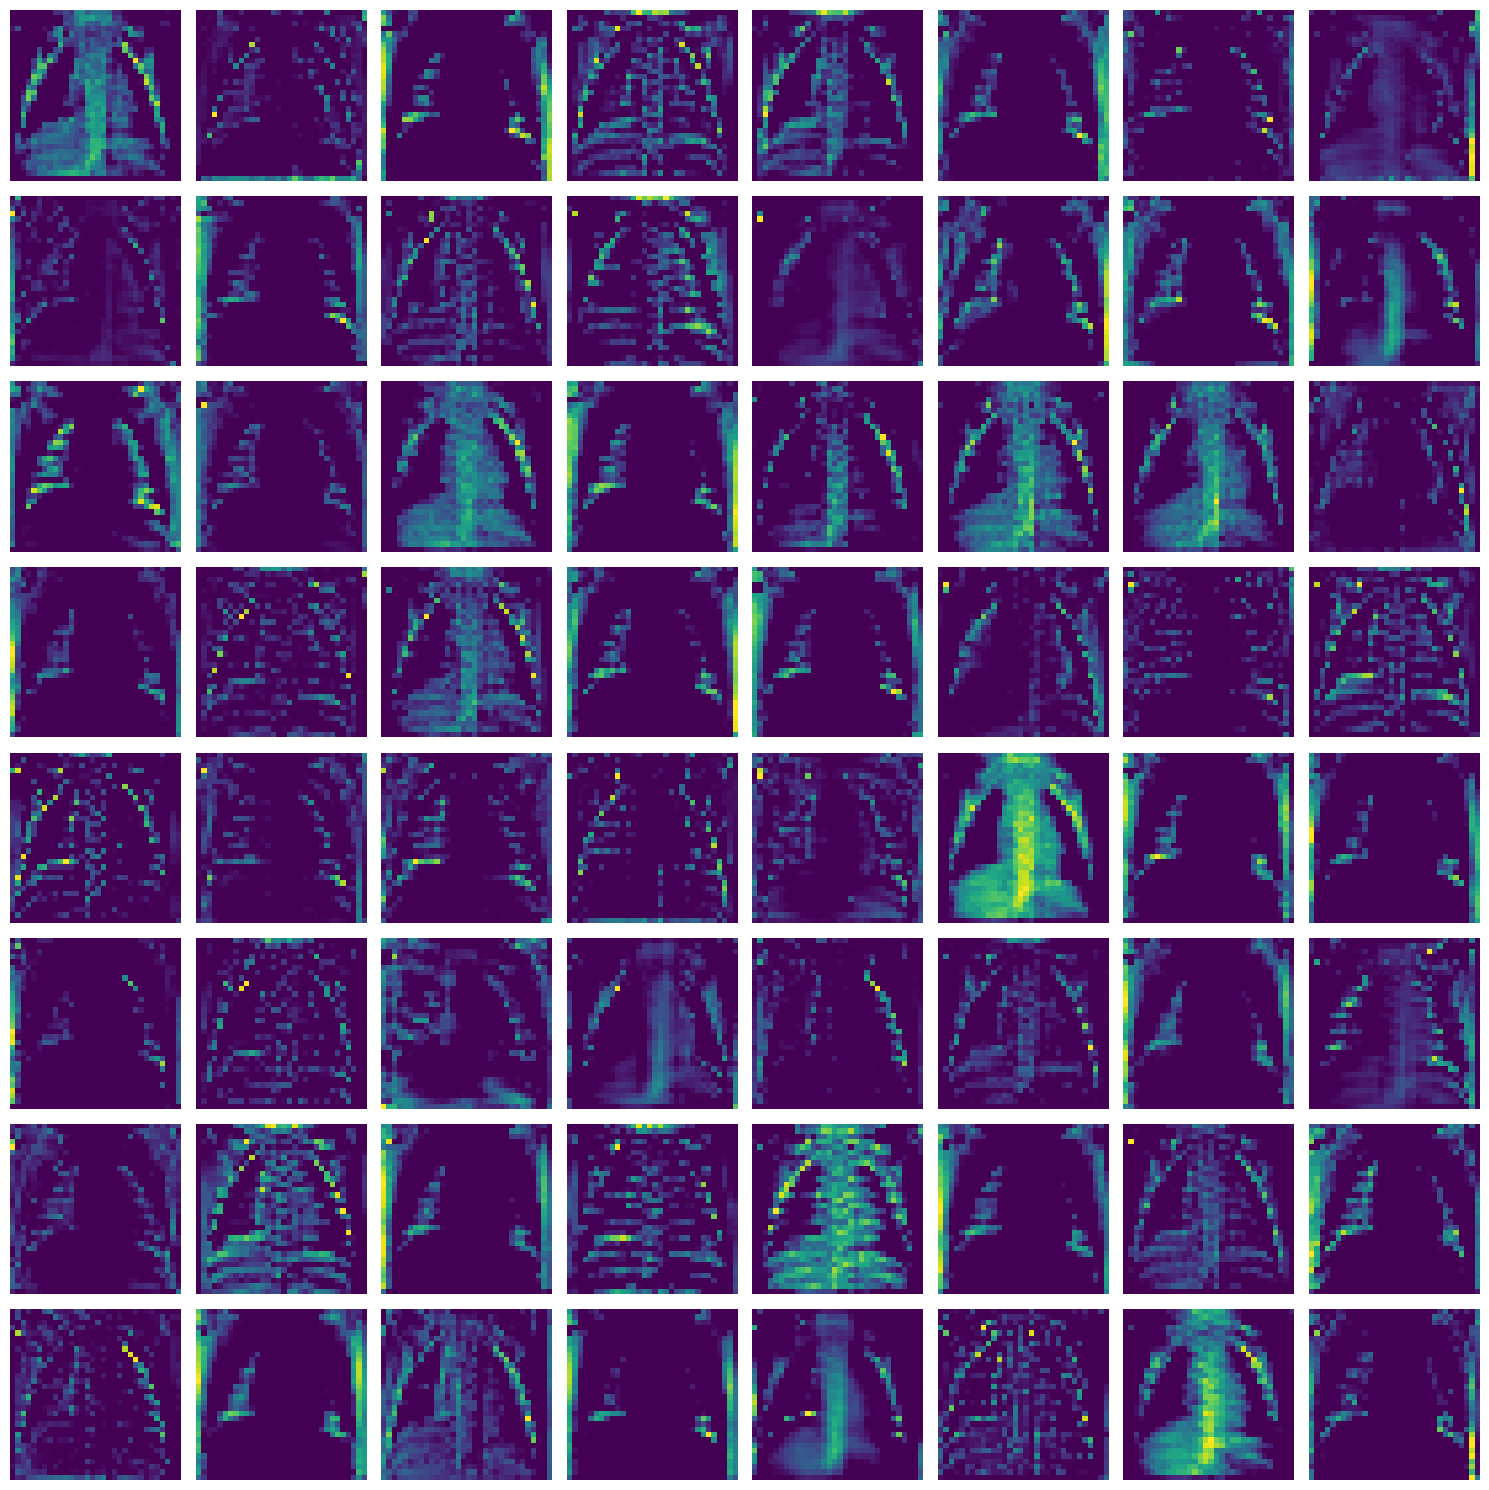

In [15]:
from keras.models import Model

conv_layer_name = "activation"
feature_map_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps)))  

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
Feature Maps Shape: (1, 16, 16, 128)


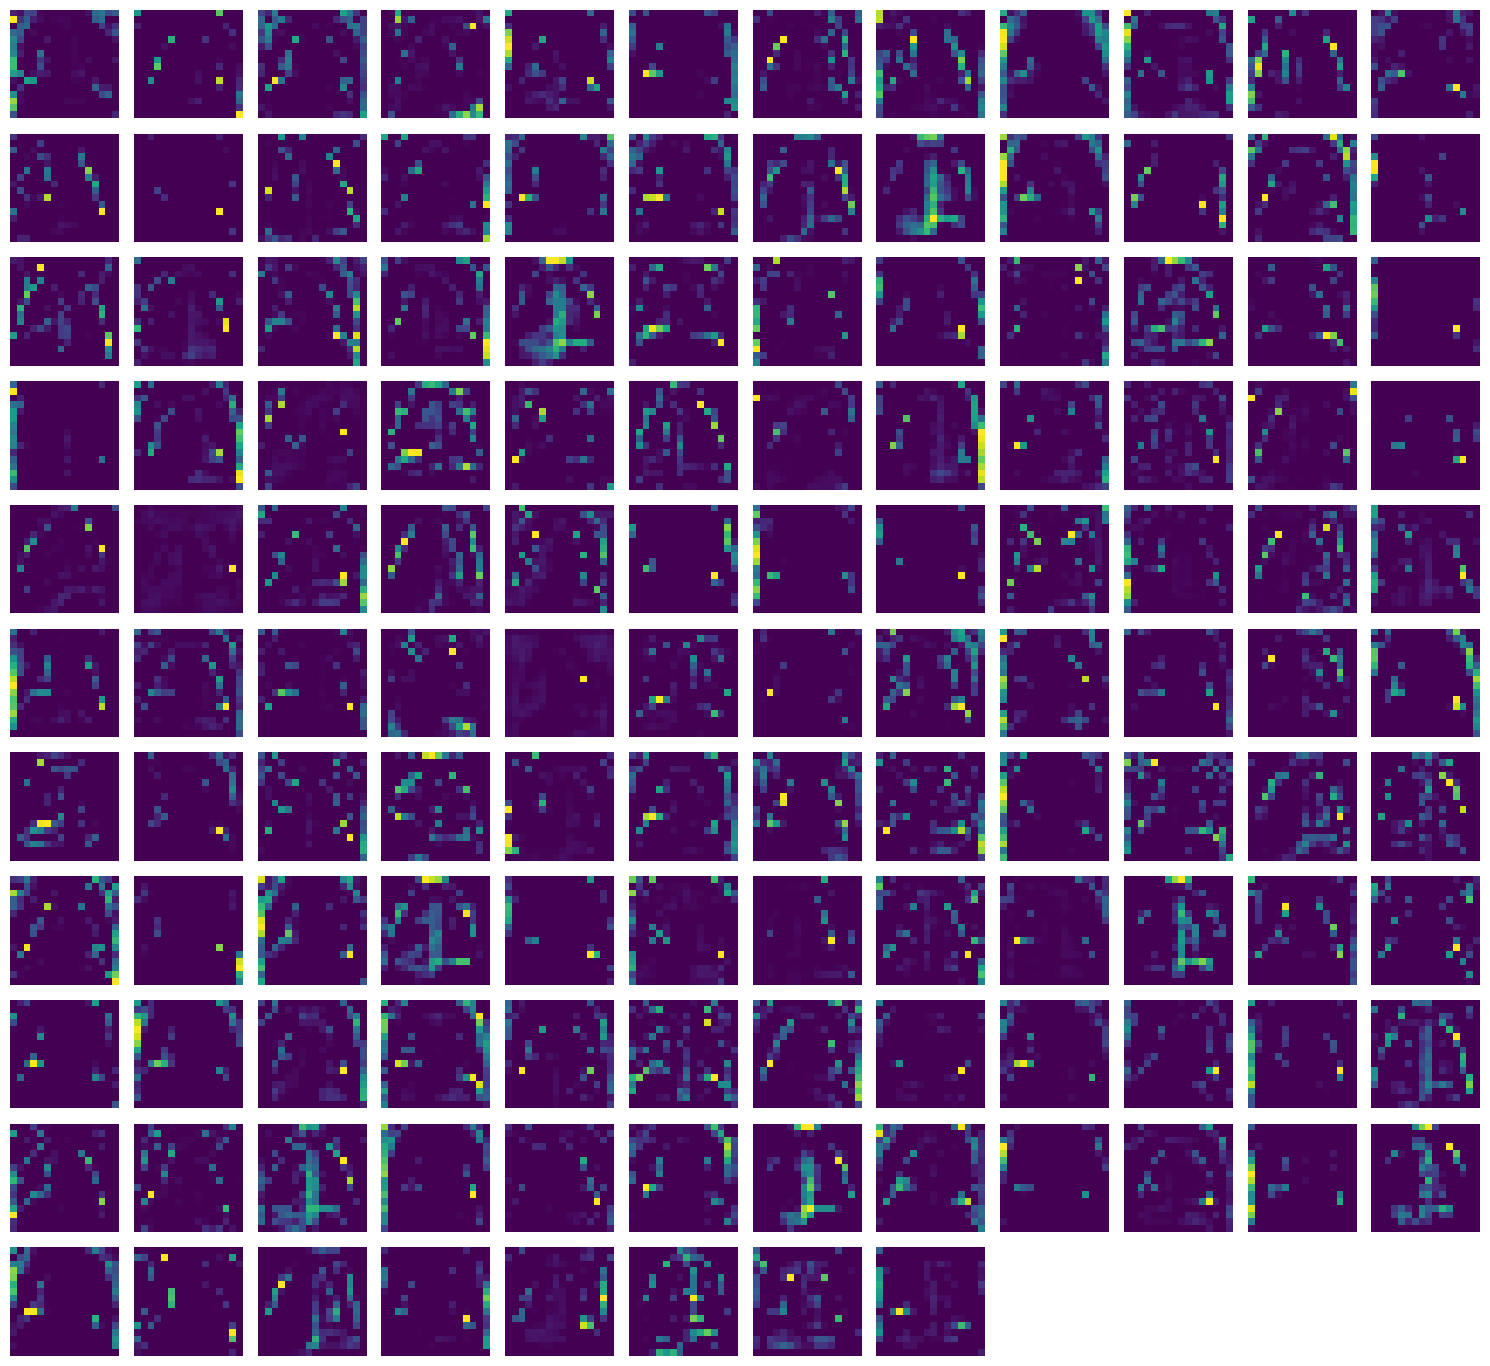

In [16]:
from keras.models import Model

conv_layer_name = "activation_1"
feature_map_model1 = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model1.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  # Expected: (1, 16, 16, 128)

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


In [17]:
import numpy as np
from tensorflow.keras.models import Model

conv_layer_name = "dense"
latent_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

latent_vectors = latent_model.predict(X_test[:10])

for i, vector in enumerate(latent_vectors):
    print(f"Latent vector for test image {i + 1}:")
    print(vector)
    print("-" * 50)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step
Latent vector for test image 1:
[ 0.          0.          0.         29.423273    0.          0.
  0.         48.907276    0.          0.          0.          8.2256975
 49.416275    0.          0.          0.          0.          0.
 26.103167    0.          0.          0.          6.1661477   0.
  0.         25.130337    0.          0.          0.          0.
  0.          5.3663726   4.197673   23.562563    0.          3.5752406
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         13.452647   11.702199    9.838635
 22.001385   34.587154    0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 18.978857    0.         28.314642    0.          0.          0.
  0.          0.          0.         19.321806    0.          0.
  0.          0.         28.74282     0.          0.          0.

In [ ]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

In [ ]:
latent_vectors.shape

In [ ]:
encoder = autoencoder.get_layer("Complex_Encoder")  
decoder = autoencoder.get_layer("Complex_Decoder")  

encoded_data = encoder.predict(X_test)

y_test = decoder.predict(encoded_data)

n = 15 
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
encoded_data.shape

In [ ]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    # No Flatten, keeping feature maps
    return models.Model(inputs, x, name="Encoder")

def build_decoder(target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(16, 16, 128))  # Assuming feature maps size here

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Decoder")

In [ ]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_encoder(input_shape)
    decoder = build_decoder(target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    feature_maps = encoder(inputs)  # Outputs feature maps
    reconstructed = decoder(feature_maps)  # Decoder takes feature maps as input

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

# Training the autoencoder
autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
) 


In [ ]:

# Predicting decoded images
decoded_imgs = autoencoder.predict(X_test)

# Displaying original and reconstructed images
n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [ ]:
encoder = autoencoder.get_layer("Encoder")
encoder.summary() 

In [ ]:
fmaps_train = encoder.predict(X_train)
fmaps_test = encoder.predict(X_test)
def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

len(fmaps_train)

In [ ]:
len(fmaps_test)